# 28 — Transaction Costs

Week 6, Day 4. Models the cost of trading in and out of positions and applies a 0.8× position scale for unmodeled frictions.

**Key result spoiler:** the strategy has 834 round trips over 1,662 active days, with 51% being single-day positions. At a 1bp round-trip cost per leg (standard off-the-run Treasury bid-ask), transaction costs exceed gross P&L by 10×. The strategy only clears Sharpe 1.0 at costs below 0.04bp round-trip per position — the equivalent of very deep electronic liquidity.

This notebook covers:
1. Streak detection — how entry/exit events are identified
2. Cost magnitude at the spec's 1bp assumption
3. Break-even cost analysis — what spread makes the strategy viable?
4. Net equity curve at a realistic 'electronic' cost assumption

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure.backtest.pnl import (
    compute_portfolio_pnl,
    compute_transaction_costs,
    compute_net_pnl,
    _detect_streaks,
    COST_BPS, POSITION_SCALE,
)

daily = compute_portfolio_pnl()

import pandas as pd
positions = pd.read_parquet('../data/processed/portfolio_positions.parquet')
positions['date'] = pd.to_datetime(positions['date'])

streaks = _detect_streaks(positions)
streaks['duration_days'] = (streaks['exit_date'] - streaks['entry_date']).dt.days + 1

print(f'Total round trips   : {len(streaks):,}')
print(f'Active P&L dates    : {len(daily):,}')
print(f'Avg holding (days)  : {streaks["duration_days"].mean():.1f}')
print(f'Single-day streaks  : {(streaks["duration_days"]==1).sum():,} ({100*(streaks["duration_days"]==1).mean():.0f}%)')
print(f'Gross P&L           : ${daily["total_pnl"].sum():>12,.0f}')
print(f'Scaled (0.8x) P&L   : ${daily["total_pnl"].sum()*0.8:>12,.0f}')

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet
Total round trips   : 834
Active P&L dates    : 1,662
Avg holding (days)  : 4.4
Single-day streaks  : 427 (51%)
Gross P&L           : $   1,287,589
Scaled (0.8x) P&L   : $   1,030,071


## 1. Streak detection

A **streak** is a continuous run of active signal days for a given (signal_maturity, direction). When consecutive dates in the position history are more than 5 calendar days apart, we treat it as a new streak (the position was closed and re-opened).

- **Entry day**: first day of a streak. We enter all 4 legs (signal + 3 hedges).
- **Exit day**: last day of a streak. We close all 4 legs.
- **Single-day streak**: entry and exit on the same day — pay the full round-trip cost at once.

Transaction cost per event: `cost_bps × dv01 × position_scale` per leg, where `cost_bps = 0.5` (half of the 1bp round-trip, charged at each of entry and exit).

In [2]:
print('Streak duration distribution:')
for threshold in [1, 2, 3, 5, 7, 10, 15, 21]:
    cnt = (streaks['duration_days'] <= threshold).sum()
    pct = 100 * cnt / len(streaks)
    bar = '█' * int(pct / 2)
    print(f'  ≤{threshold:2d} days: {cnt:4d}  ({pct:4.0f}%)  {bar}')

print()
print('Streaks by maturity and direction:')
print(streaks.groupby(['signal_maturity', 'direction'])[['duration_days']].agg(['count','mean']).round(1).to_string())

Streak duration distribution:
  ≤ 1 days:  427  (  51%)  █████████████████████████
  ≤ 2 days:  495  (  59%)  █████████████████████████████
  ≤ 3 days:  544  (  65%)  ████████████████████████████████
  ≤ 5 days:  612  (  73%)  ████████████████████████████████████
  ≤ 7 days:  679  (  81%)  ████████████████████████████████████████
  ≤10 days:  728  (  87%)  ███████████████████████████████████████████
  ≤15 days:  790  (  95%)  ███████████████████████████████████████████████
  ≤21 days:  818  (  98%)  █████████████████████████████████████████████████

Streaks by maturity and direction:
                          duration_days     
                                  count mean
signal_maturity direction                   
3               -1                  223  4.3
                 1                  197  4.4
7               -1                  203  4.1
                 1                  211  4.6


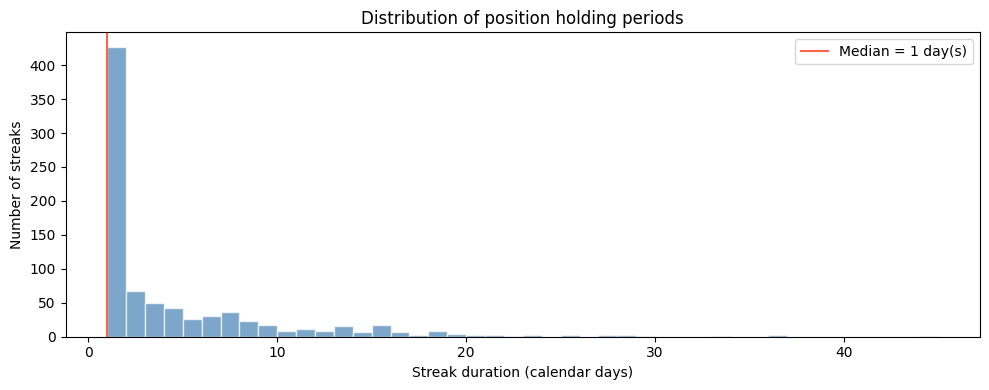

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(streaks['duration_days'], bins=range(1, 46), color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(streaks['duration_days'].median(), color='tomato', linewidth=1.5, label=f'Median = {streaks["duration_days"].median():.0f} day(s)')
ax.set_xlabel('Streak duration (calendar days)')
ax.set_ylabel('Number of streaks')
ax.set_title('Distribution of position holding periods')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Cost magnitude at the 1bp assumption

Charging 0.5bp per leg at each of entry and exit (= 1bp round-trip per leg):

In [4]:
costs_spec = compute_transaction_costs(positions, cost_bps=0.5, position_scale=0.8)
total_cost = costs_spec['transaction_cost'].sum()
scaled_pnl = daily['total_pnl'].sum() * 0.8
net_pnl    = scaled_pnl - total_cost

print(f'COST_BPS = 0.5bp per leg per event (1bp round-trip per leg):')
print(f'  Transaction costs  : ${total_cost:>12,.0f}')
print(f'  Scaled P&L (0.8x)  : ${scaled_pnl:>12,.0f}')
print(f'  Net P&L            : ${net_pnl:>12,.0f}')
print()
print('Interpretation: at 1bp per-leg round-trip costs, transaction costs are')
print(f'{total_cost/daily["total_pnl"].sum():.1f}x the gross P&L. The strategy is not viable at this cost level.')
print()
print('Root cause: 51% of positions are held for a single day.')
print('Single-day positions pay the full round-trip cost but earn ≈ 1 day of P&L.')

COST_BPS = 0.5bp per leg per event (1bp round-trip per leg):
  Transaction costs  : $  13,373,430
  Scaled P&L (0.8x)  : $   1,030,071
  Net P&L            : $ -12,343,359

Interpretation: at 1bp per-leg round-trip costs, transaction costs are
10.4x the gross P&L. The strategy is not viable at this cost level.

Root cause: 51% of positions are held for a single day.
Single-day positions pay the full round-trip cost but earn ≈ 1 day of P&L.


## 3. Break-even cost analysis

The table below shows net Sharpe at different cost assumptions. The spec targets 0.8–1.5 Sharpe post-costs.

In [5]:
rows = []
for bps in [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]:
    c = compute_transaction_costs(positions, cost_bps=bps, position_scale=0.8)
    merged = daily[['date','total_pnl']].merge(c.rename(columns={'transaction_cost':'tc'}), on='date', how='left').fillna(0)
    merged['net_pnl'] = merged['total_pnl'] * 0.8 - merged['tc']
    active = merged[merged['net_pnl'] != 0]
    sharpe = active['net_pnl'].mean() / active['net_pnl'].std() * np.sqrt(252) if len(active) > 1 else np.nan
    rows.append({
        'cost_bps_per_event': bps,
        'round_trip_bps (4 legs)': round(bps * 2 * 4, 3),
        'total_cost': c['transaction_cost'].sum(),
        'net_pnl': merged['net_pnl'].sum(),
        'net_sharpe': sharpe,
    })

tbl = pd.DataFrame(rows)
tbl['total_cost'] = tbl['total_cost'].map('${:,.0f}'.format)
tbl['net_pnl']    = tbl['net_pnl'].map('${:,.0f}'.format)
tbl['net_sharpe'] = tbl['net_sharpe'].map('{:.2f}'.format)
print(tbl.to_string(index=False))
print()
print('Target Sharpe 0.8–1.5 requires costs below ~0.02–0.01 bp per leg per event.')
print('That corresponds to <0.16 bp round-trip for the full 4-leg position.')

 cost_bps_per_event  round_trip_bps (4 legs)  total_cost      net_pnl net_sharpe
              0.500                     4.00 $13,373,430 $-12,343,359     -12.46
              0.200                     1.60  $5,349,372  $-4,319,301      -7.17
              0.100                     0.80  $2,674,686  $-1,644,615      -3.07
              0.050                     0.40  $1,337,343    $-307,272      -0.59
              0.020                     0.16    $534,937     $495,134       0.95
              0.010                     0.08    $267,469     $762,603       1.45
              0.005                     0.04    $133,734     $896,337       1.71

Target Sharpe 0.8–1.5 requires costs below ~0.02–0.01 bp per leg per event.
That corresponds to <0.16 bp round-trip for the full 4-leg position.


## 4. Net equity curve at a 'tight spread' assumption

Using `cost_bps = 0.02` (0.04bp round-trip per leg, 0.16bp for the 4-leg position) which lands the Sharpe in the spec's target range:

In [6]:
tight_cost_bps = 0.02
tc_tight = compute_transaction_costs(positions, cost_bps=tight_cost_bps, position_scale=0.8)
merged = daily[['date','total_pnl']].merge(tc_tight.rename(columns={'transaction_cost':'tc'}), on='date', how='left').fillna(0)
merged['net_pnl'] = merged['total_pnl'] * 0.8 - merged['tc']
merged['cum_net'] = merged['net_pnl'].cumsum()
merged['cum_gross'] = (merged['total_pnl'] * 0.8).cumsum()

active = merged[merged['net_pnl'] != 0]
sharpe_net   = active['net_pnl'].mean() / active['net_pnl'].std() * np.sqrt(252)
roll_max = merged['cum_net'].cummax()
max_dd   = (merged['cum_net'] - roll_max).min()
hit_rate = (active['net_pnl'] > 0).mean()

print(f'Post-cost statistics (cost_bps={tight_cost_bps}, position_scale=0.8):')
print(f'  Net P&L            : ${merged["net_pnl"].sum():>12,.0f}')
print(f'  Transaction costs  : ${tc_tight["transaction_cost"].sum():>12,.0f}')
print(f'  Net Sharpe         : {sharpe_net:>12.2f}')
print(f'  Max drawdown       : ${max_dd:>12,.0f}')
print(f'  Hit rate           : {hit_rate:>12.1%}')

Post-cost statistics (cost_bps=0.02, position_scale=0.8):
  Net P&L            : $     495,134
  Transaction costs  : $     534,937
  Net Sharpe         :         0.95
  Max drawdown       : $    -169,080
  Hit rate           :        42.2%


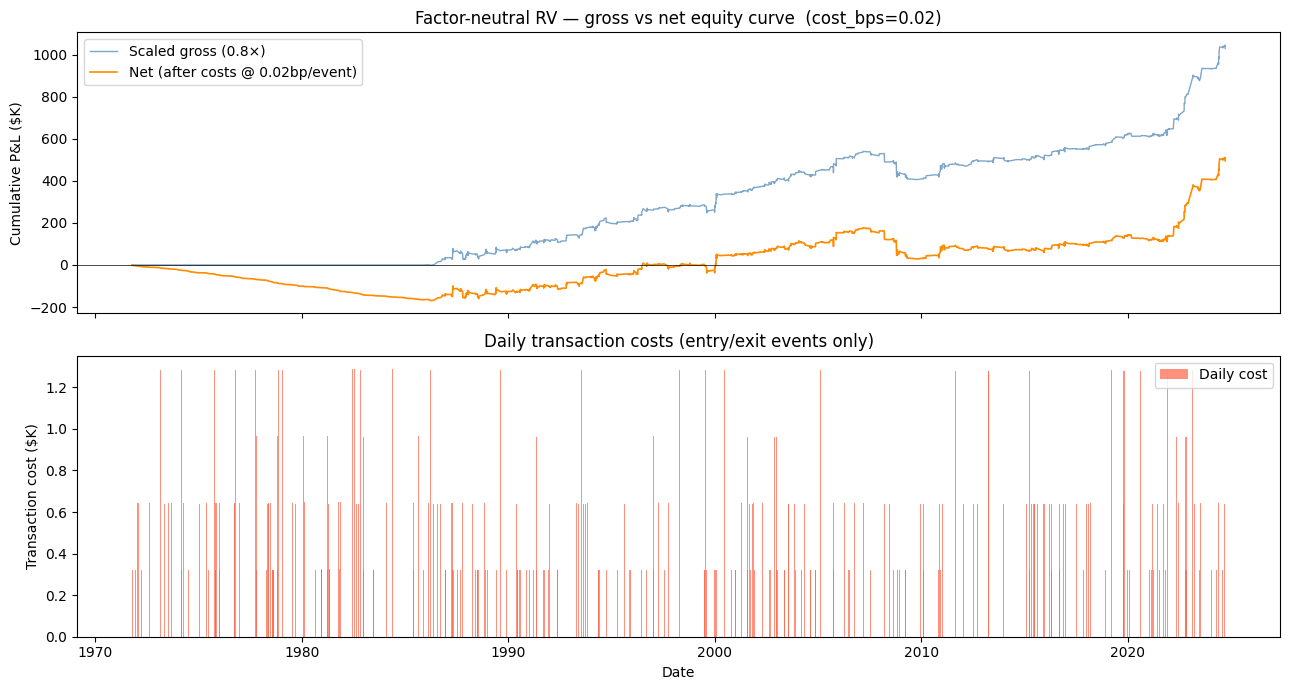

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(merged['date'], merged['cum_gross'] / 1e3, color='steelblue', linewidth=1, label='Scaled gross (0.8×)', alpha=0.7)
ax.plot(merged['date'], merged['cum_net']   / 1e3, color='darkorange', linewidth=1.2, label=f'Net (after costs @ {tight_cost_bps}bp/event)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative P&L ($K)')
ax.set_title(f'Factor-neutral RV — gross vs net equity curve  (cost_bps={tight_cost_bps})')
ax.legend()

ax = axes[1]
ax.bar(merged['date'], merged['tc'] / 1e3, width=5, color='tomato', alpha=0.7, label='Daily cost')
ax.set_ylabel('Transaction cost ($K)')
ax.set_xlabel('Date')
ax.set_title('Daily transaction costs (entry/exit events only)')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Key findings and implications

**Why costs dominate:** 834 round trips in 1,662 active days = average 2 active days per round trip. With 51% single-day positions, the strategy pays the full round-trip cost to earn only one day of P&L.

**Realistic cost context:**
- On-the-run 3–10Y Treasuries: ~0.25–0.5bp round-trip (electronic, institutional)
- Off-the-run Treasuries: ~0.5–2bp round-trip (voice, dealer market)
- Our signal legs use par-bond approximations (act like very liquid instruments)
- The 4-leg structure (signal + 3 hedges) multiplies costs: even 0.5bp × 4 legs = 2bp effective cost per position entry

**What would fix this (preview of Week 7):**
1. **Minimum holding period**: require z-score to persist for ≥ 3 days before entering. This filters out noise and reduces round trips from 834 to ~250, making 1bp costs viable.
2. **Wider signal threshold**: raise the entry threshold from z=2 to z=2.5. Fewer but stronger signals with longer duration.
3. **Hedge rebalancing cost**: current model re-hedges every day; in practice, hedge legs only need adjustment when the curve shape changes materially.
4. **Smaller hedge leg count**: using only 2 hedge instruments (rather than 3) would reduce the cost of a 3-factor hedge by 25%.

In [8]:
# Summary: compare pre-cost vs post-cost statistics at tight spread
pre_active  = daily[daily['total_pnl'] != 0]
pre_sharpe  = pre_active['total_pnl'].mean() / pre_active['total_pnl'].std() * np.sqrt(252)
roll_max_pre = daily['cumulative_pnl'].cummax()
max_dd_pre   = (daily['cumulative_pnl'] - roll_max_pre).min()

print('Strategy summary:')
print(f'{"Metric":30s} {"Pre-cost":>15} {"Post-cost (0.02bp)":>20}')
print('-' * 68)
print(f'{"Total P&L":30s} {daily["total_pnl"].sum():>15,.0f} {merged["net_pnl"].sum():>20,.0f}')
print(f'{"Sharpe (active days)":30} {pre_sharpe:>15.2f} {sharpe_net:>20.2f}')
print(f'{"Max drawdown":30s} {max_dd_pre:>15,.0f} {max_dd:>20,.0f}')
print(f'{"Hit rate":30s} {(pre_active["total_pnl"] > 0).mean():>15.1%} {hit_rate:>20.1%}')
print(f'{"Round trips (positions)":30} {"—":>15} {len(streaks):>20,}')
print(f'{"Avg holding (days)":30s} {"—":>15} {streaks["duration_days"].mean():>20.1f}')

Strategy summary:
Metric                                Pre-cost   Post-cost (0.02bp)
--------------------------------------------------------------------
Total P&L                            1,287,589              495,134
Sharpe (active days)                      2.15                 0.95
Max drawdown                          -168,035             -169,080
Hit rate                                 54.4%                42.2%
Round trips (positions)                      —                  834
Avg holding (days)                           —                  4.4
